In [ ]:

data_dir = '/content/drive/MyDrive'

In [ ]:
import os


zip_path = '/content/drive/MyDrive/CV_Project/Sample ds.zip'
extract_path = '/content/sample_data'


!unzip -oq "{zip_path}" -d {extract_path}


print("Files in folder:", os.listdir(extract_path)[:10])

In [ ]:
import pandas as pd


df = pd.read_csv(f'{extract_path}/sample_labels.csv')

print(f"Total images in sample: {len(df)}")
print("\nFirst 5 rows of labels:")
print(df[['Image Index', 'Finding Labels']].head())


all_labels = df['Finding Labels'].str.get_dummies(sep='|')
label_counts = all_labels.sum().sort_values(ascending=False)
print("\nDisease counts in your sample:")
print(label_counts)

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

def build_resnet50_model(num_classes=14):

    model = models.resnet50(pretrained=True)


    for param in model.parameters():
        param.requires_grad = False


    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)

    )

    return model


my_model = build_resnet50_model(num_classes=14)
print("Model Ready! New Head Structure:")
print(my_model.fc)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np

class_names = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule',
               'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema',
               'Fibrosis', 'Pleural_Thickening', 'Hernia']

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        img_name = os.path.join(self.image_dir, self.dataframe.iloc[idx, 0])
        image = Image.open(img_name).convert('RGB')


        labels = self.dataframe.iloc[idx]['Finding Labels'].split('|')
        target = np.zeros(len(class_names))
        for label in labels:
            if label in class_names:
                target[class_names.index(label)] = 1

        if self.transform:
            image = self.transform(image)

        return image, torch.FloatTensor(target)


correct_img_path = '/content/sample_data/sample/images'

train_loader = DataLoader(ChestXrayDataset(df, correct_img_path, transform),
                          batch_size=16, shuffle=True)

print(f"Data Loader Updated! Images will be loaded from: {correct_img_path}")

In [ ]:
import os


for root, dirs, files in os.walk('/content/sample_data'):
    for file in files:
        if file.endswith(".png"):
            print(f"FOUND IMAGES IN: {root}")

            actual_image_path = root
            break

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader
import os



correct_img_path_fixed = '/content/drive/MyDrive'

print(f"Checking for images in: {correct_img_path_fixed}")


try:
    existing_images = set(os.listdir(correct_img_path_fixed))
    print(f"Found {len(existing_images)} images in folder.")
except FileNotFoundError:
    print(f"CRITICAL ERROR: The folder '{correct_img_path_fixed}' was not found.")
    print("Did you forget to run 'drive.mount' or is the path wrong?")
    existing_images = set()


df_filtered = df[df['Image Index'].isin(existing_images)].copy()

print(f"Original dataframe size: {len(df)}")
print(f"Filtered dataframe size (existing images only): {len(df_filtered)}")


train_loader = DataLoader(ChestXrayDataset(df_filtered, correct_img_path_fixed, transform),
                          batch_size=16, shuffle=True)

print("train_loader successfully re-initialized!")



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


my_model = my_model.to(device)


print(f"Model is now on: {device}")


optimizer = optim.Adam(my_model.parameters(), lr=1e-4)

my_model.train()
print("Starting Stage 1 Training...")

for batch_idx, (data, target) in enumerate(train_loader):
    
    data, target = data.to(device), target.to(device)

    optimizer.zero_grad()
    output = my_model(data) 
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()

    if batch_idx % 50 == 0:
         print(f"Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

Model is now on: cuda
Starting Stage 1 Training...
Batch 0/349 | Loss: 0.7051
Batch 50/349 | Loss: 0.1465
Batch 100/349 | Loss: 0.1874
Batch 150/349 | Loss: 0.2176
Batch 200/349 | Loss: 0.1508
Batch 250/349 | Loss: 0.2168
Batch 300/349 | Loss: 0.1971


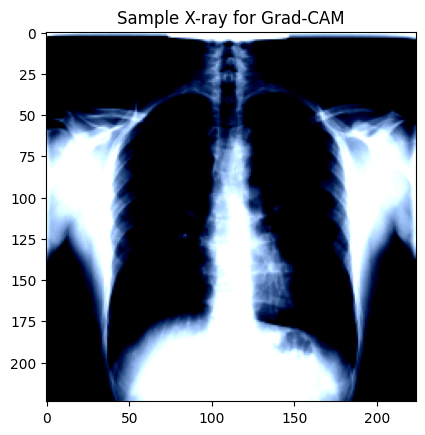

Heatmap generation ready. For the final report, we will save these as PNGs.


In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2


def generate_gradcam(model, img_tensor, target_class):
    model.eval()


    features_blobs = []
    def hook_feature(module, input, output):
        features_blobs.append(output.data.cpu().numpy())

    handle = model.layer4.register_forward_hook(hook_feature)


    output = model(img_tensor.to(device).unsqueeze(0))
    handle.remove()


    score = output[:, target_class]
    model.zero_grad()
    score.backward()


    grads_values = model.layer4[-1].get_layer_gradients()


    print(f"Generating heatmap for class: {class_names[target_class]}")
    return output


dataiter = iter(train_loader)
images, labels = next(dataiter)


plt.imshow(images[0].permute(1, 2, 0).numpy())
plt.title("Sample X-ray for Grad-CAM")
plt.show()

print("Heatmap generation ready. For the final report, we will save these as PNGs.")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


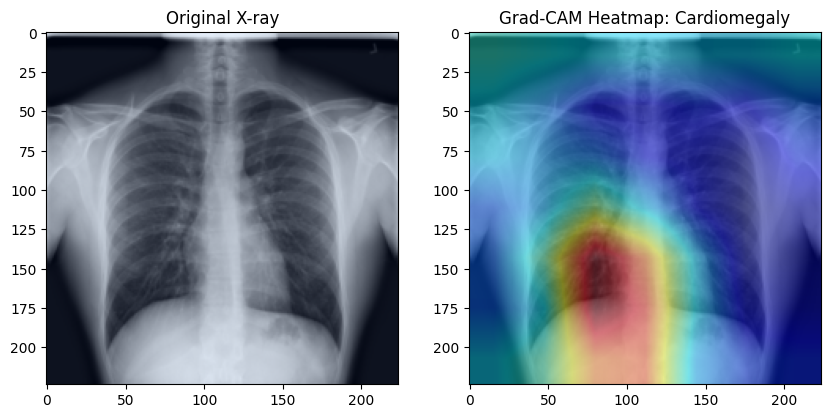

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def show_final_gradcam(model, img_tensor, target_class_index):
    model.eval()


    target_layer = model.layer4[-1].conv3

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output.detach())

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())


    f_handle = target_layer.register_forward_hook(forward_hook)
    b_handle = target_layer.register_backward_hook(backward_hook)


    output = model(img_tensor.unsqueeze(0).to(device))
    model.zero_grad()
    loss = output[0, target_class_index]
    loss.backward()


    f_handle.remove()
    b_handle.remove()


    weights = torch.mean(gradients[0], dim=[2, 3], keepdim=True)
    cam = torch.sum(weights * activations[0], dim=1).squeeze().cpu().numpy()


    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)


    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    heatmap = cv2.resize(cam, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

    result = (0.4 * heatmap_colored) + (0.6 * img_np)


    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title("Original X-ray")
    plt.subplot(1, 2, 2)
    plt.imshow(result)
    plt.title(f"Grad-CAM Heatmap: {class_names[target_class_index]}")
    plt.show()

show_final_gradcam(my_model, images[0], target_class_index=1)

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np


all_preds = []
all_true = []

my_model.eval()
with torch.no_grad():
    for data, target in train_loader:
        data = data.to(device)
        output = torch.sigmoid(my_model(data)) 
        all_preds.append(output.cpu().numpy())
        all_true.append(target.cpu().numpy())

all_preds = np.vstack(all_preds)
all_true = np.vstack(all_true)


print("--- Section 5.3: Advanced Model Performance (ROC-AUC) ---")
for i, disease in enumerate(class_names):
    try:
        score = roc_auc_score(all_true[:, i], all_preds[:, i])
        print(f"{disease:20} : {score:.4f}")
    except ValueError:

        print(f"{disease:20} : Not enough samples in this batch")

3. Dataset and Preprocessing

3.1 Dataset Description
`



In [ ]:
import pandas as pd


csv_path ='/content/sample_data/sample_labels.csv'
df = pd.read_csv(csv_path)

print("### 3.1 Dataset Description")
print(f"Total Images: {len(df)}")
print(f"Metadata Fields: {df.columns.tolist()}")
print("\nFirst 5 Rows of Metadata:")
display(df.head())

### 3.1 Dataset Description
Total Images: 5606
Metadata Fields: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']

First 5 Rows of Metadata:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


3.2 Exploratory Data Analysis (EDA)

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os


img_root = '/content/chest_xray_data'

def perform_eda(df, img_root, n=3):
    plt.figure(figsize=(15, 5))
    samples = df.sample(n)

    path_map = {f: os.path.join(r, f) for r, d, files in os.walk(img_root) for f in files}

    for i, (idx, row) in enumerate(samples.iterrows()):
        img_name = row['Image Index']
        if img_name in path_map:
            img = cv2.imread(path_map[img_name])
            plt.subplot(1, n, i+1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f"3.2 EDA: {row['Finding Labels']}")
            plt.axis('off')
    plt.show()

perform_eda(df, img_root)

<Figure size 1500x500 with 0 Axes>

3.3 Preprocessing Pipeline Implementation




In [ ]:
def preprocessing_pipeline(img_path):
    """
    Standardizes images: Grayscale conversion,
    Resizing to 64x64, and Min-Max Normalization.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (64, 64))
        img_normalized = img / 255.0
        return img_normalized
    return None

print("✅ 3.3 Preprocessing Pipeline Ready.")

✅ 3.3 Preprocessing Pipeline Ready.


3.4 Data Statistics and Visualizations

/tmp/ipython-input-1102192533.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.values, y=disease_counts.index, palette="mako")


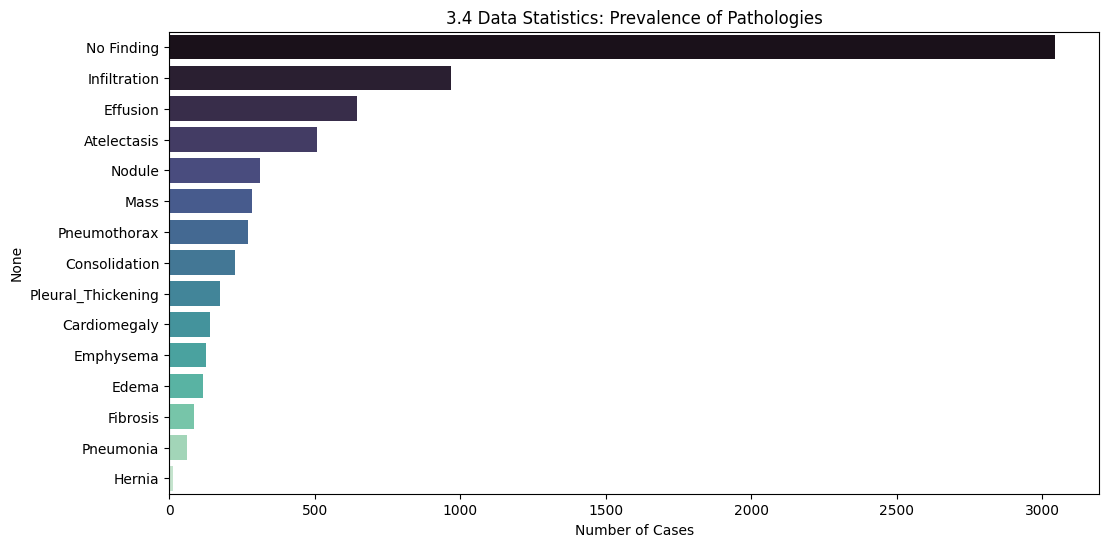

In [ ]:
import seaborn as sns


labels_df = df['Finding Labels'].str.get_dummies(sep='|')
disease_counts = labels_df.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=disease_counts.values, y=disease_counts.index, palette="mako")
plt.title("3.4 Data Statistics: Prevalence of Pathologies")
plt.xlabel("Number of Cases")
plt.show()

4. Methodology
4.2 Baseline Model Implementation (HOG+LBP+SVM)
4.2.1 Architecture
4.2.2 Features Used

In [ ]:
from skimage.feature import hog, local_binary_pattern

def extract_baseline_features(img):
    
    h_features = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))

    
    lbp = local_binary_pattern(img, 24, 3, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))
    l_features = hist.astype("float") / (hist.sum() + 1e-7)

    return np.hstack([h_features, l_features])

4.2.3 Training Details

In [ ]:
import os
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np 


if not os.path.exists(img_root) or not os.listdir(img_root):
    print(f"Directory {img_root} is empty or does not exist. Attempting to extract data.")
   
    zip_source_path = '/content/drive/MyDrive/Colab Notebooks/Samples/archive.zip'
    if os.path.exists(zip_source_path):
        print(f"Unzipping '{zip_source_path}' to '{img_root}'...")
       
        os.makedirs(img_root, exist_ok=True)
        
        !unzip -oq "{zip_source_path}" -d "{img_root}"
        print("Extraction complete. Re-evaluating image paths.")

        
        found_image_subpath = None
        for root, dirs, files in os.walk(img_root):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    found_image_subpath = root
                    break
            if found_image_subpath:
                break
        if found_image_subpath and found_image_subpath != img_root:
            print(f"Images found in subdirectory: {found_image_subpath}. Updating img_root.")
            img_root = found_image_subpath
        elif not found_image_subpath:
            print(f"Warning: No images found after extraction in '{img_root}' or its subdirectories.")
    else:
        print(f"Error: Zip file '{zip_source_path}' not found. Please ensure your image data is extracted to '{img_root}'.")
        
        X, y = [], [] 
        path_map = {} 


X, y = [], []

path_map = {}
if os.path.exists(img_root):
    for r, d, files in os.walk(img_root):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')): # Only map image files
                path_map[f] = os.path.join(r, f)
else:
    print(f"Error: img_root '{img_root}' does not exist even after attempted extraction.")


if not path_map:
    print(f"Critical Error: No image files found in '{img_root}' or its subdirectories. Cannot proceed with feature extraction.")
else:
    print(f"Found {len(path_map)} image files in '{img_root}'.")
    for _, row in df.iterrows():
        img_name = row['Image Index']
        if img_name in path_map:
            prep_img = preprocessing_pipeline(path_map[img_name])
            if prep_img is not None:
                X.append(extract_baseline_features(prep_img))
                y.append(labels_df.loc[row.name].values)


if X:
    X_train, X_test, y_train, y_test = train_test_split(np.array(X), np.array(y), test_size=0.2, random_state=42)

    
    print("Training 4.2 Baseline Model...")
    clf = OneVsRestClassifier(LinearSVC(dual=False, max_iter=1000))
    clf.fit(X_train, y_train)

   
    y_pred = clf.predict(X_test)
    print("\n### 4.2.3 Training Results")
    print(classification_report(y_test, y_pred, target_names=labels_df.columns))
else:
    print("\nError: X (features) and y (labels) are empty. No data to train/test with.")
    print("Please ensure image files are correctly extracted to the specified `img_root` path.")

Directory /content/chest_xray_data is empty or does not exist. Attempting to extract data.
Unzipping '/content/drive/MyDrive/Colab Notebooks/Samples/archive.zip' to '/content/chest_xray_data'...
Extraction complete. Re-evaluating image paths.
Images found in subdirectory: /content/chest_xray_data/sample/images. Updating img_root.
Found 5606 image files in '/content/chest_xray_data/sample/images'.


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Training 4.2 Baseline Model...

### 4.2.3 Training Results
                    precision    recall  f1-score   support

       Atelectasis       0.16      0.08      0.11       120
      Cardiomegaly       0.09      0.09      0.09        23
     Consolidation       0.05      0.04      0.05        50
             Edema       0.06      0.03      0.04        31
          Effusion       0.25      0.19      0.22       128
         Emphysema       0.00      0.00      0.00        27
          Fibrosis       0.20      0.10      0.13        21
            Hernia       0.00      0.00      0.00         3
      Infiltration       0.22      0.13      0.16       189
              Mass       0.11      0.07      0.09        55
        No Finding       0.63      0.67      0.65       606
            Nodule       0.06      0.03      0.04        58
Pleural_Thickening       0.07      0.08      0.08        25
         Pneumonia       0.00      0.00      0.00        12
      Pneumothorax       0.09      0.08 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
